In [68]:
import numpy as np
import matplotlib.pyplot as plt

In [69]:
# Normalmente representamos um arranjo em python usando listas

a=[1,2,3,4,5]

for i in range (len(a)):
  a[i]=a[i]*2
print(a)

[2, 4, 6, 8, 10]


In [70]:
# Em numpy, as operações são vetores, portanto podem ser executadas em tempo constante

a=np.array([1,2,3,4,5])
print(a*3)

[ 3  6  9 12 15]


In [71]:
# Em arranjos bidimensionais, a vetorização é ainda mais poderosa

A=np.array([[1,2,3],[4,5,6],[7,8,9]])

print(A)


[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [72]:
print(np.average(A,axis=1)) #Média por linha

[2. 5. 8.]


In [73]:
I=np.eye(3) #Matriz identidade
print(I)


[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [74]:
print(np.dot(A,I)) #Multiplicação de matrizes

[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]


In [75]:
print(A.T) #Matriz transposta

[[1 4 7]
 [2 5 8]
 [3 6 9]]


## Regressão logística




$h(x)=\sigma(x \cdot w +b)$ onde:

$\sigma(z)= \frac {1}{1+e^{-z}}$

In [76]:
def sigmoide(z):
  return 1/(1+np.exp(-z))

In [77]:
def logistic_regression(x,w,b):
  return sigmoide(np.dot(x,w)+b)

In [78]:
def gradients(X, Y, Y_hat):
    n = X.shape[0]
    dw = np.dot(X.T, (Y_hat - Y)) / n   # (2,30) x (30,1) = (2,1)
    db = np.sum(Y_hat - Y) / n          # escalar
    return dw, db

In [79]:
def binary_cross_entropy(Y, Y_hat, eps=1e-15):
    Y_hat = np.clip(Y_hat, eps, 1 - eps)
    n = Y.shape[0]
    loss = -np.mean(Y * np.log(Y_hat) + (1 - Y) * np.log(1 - Y_hat))
    return loss

In [80]:
def     gradients_decents(X,Y,epochs=10000,learning_rate=0.1):
  d=X.shape[1]

  # inicializar os pesos w e b
  w=np.random.rand(d,1)
  b=0.0

  losses=[]

  for i in range(epochs):
    # Previsão com a regressão logística

    Y_hat=logistic_regression(X,w,b)

    #Calcular os gradientes

    dw,db=gradients(X,Y,Y_hat)

    #Atualizar os pesos

    w-=learning_rate*dw
    b-=learning_rate*db

    loss=binary_cross_entropy(Y,Y_hat)
    losses.append(loss)

  plt.plot(losses)
  plt.show()

  return w,b,losses


In [81]:
# Gerando os dados

n_alunos=30
mean=7
std=2

X=np.random.normal(loc=mean,scale=std,size=(n_alunos,2))
X=np.clip(X,0,10)
print(X)

[[ 9.50365628  4.03045074]
 [ 9.61533377  8.6371794 ]
 [ 5.10619714  6.42730561]
 [ 8.35010009  5.1061152 ]
 [ 9.11930521 10.        ]
 [ 7.82497871  5.49622713]
 [ 6.03580526 10.        ]
 [ 8.16793419  4.63831125]
 [ 4.67600039  7.5649257 ]
 [ 5.64652519  3.16475812]
 [ 8.23092792  6.26583122]
 [ 7.52324437  3.52433243]
 [ 7.10557039  6.09557338]
 [ 7.31302616  7.41521241]
 [ 6.77861281  5.99612469]
 [ 8.55692951  6.54305268]
 [ 8.19735923  6.97807517]
 [ 4.95610436 10.        ]
 [ 4.61971302  6.03180132]
 [ 6.93759044  4.5360642 ]
 [ 7.12605429  6.92012757]
 [ 8.30178005  3.92214035]
 [ 7.16961685  5.2243703 ]
 [ 6.74896756  6.65778242]
 [ 5.82407189  6.81069525]
 [ 4.02362077  6.49971945]
 [ 6.59037841 10.        ]
 [ 5.97770417  8.96490531]
 [ 6.45305613 10.        ]
 [ 8.17335843  4.82676381]]


In [82]:
# definindo os rótulos

Y=(np.average(X,axis=1)>=mean)+0.0

Y = Y.reshape(-1, 1)
Y.shape

(30, 1)

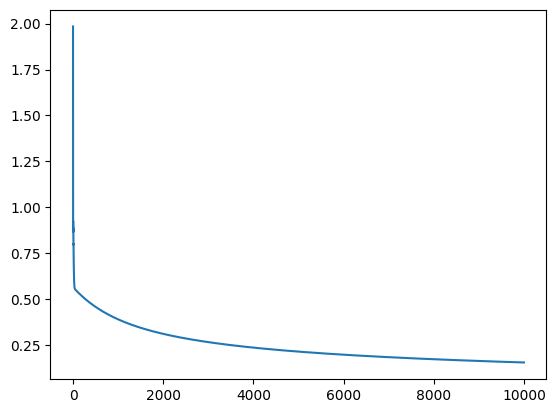

In [83]:
# Chamando a função do gradiente descendente

w,b,losses=gradients_decents(X,Y,epochs=10000,learning_rate=0.1)

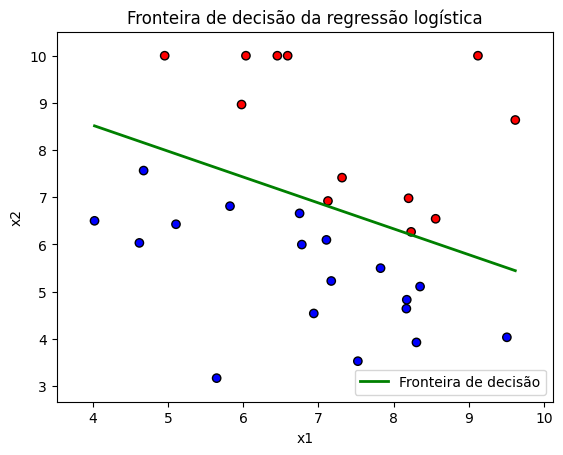

In [84]:
x1_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
x2_vals = -(w[0,0] * x1_vals + b) / w[1,0]

plt.scatter(X[:,0], X[:,1], c=Y.ravel(), cmap='bwr', edgecolors='k')
plt.plot(x1_vals, x2_vals, 'g-', linewidth=2, label='Fronteira de decisão')
plt.xlim(X[:,0].min() - 0.5, X[:,0].max() + 0.5)
plt.ylim(X[:,1].min() - 0.5, X[:,1].max() + 0.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('Fronteira de decisão da regressão logística')
plt.show()

## Vetor gradiente (derivadas parciais) de função de perda entropia cruzada binária em relação aos pesos w e b para um exemplo $x_i$.

$ \frac{\partial L}{\partial w} = (\hat{y}^{(i)}-y^{(i)}).x^{(i)}$

$ \frac{\partial L}{\partial b} = (\hat{y}^{(i)}-y^{(i)})$

## Derivadas em relação ao conjunto de dados completo X, sem vetorização.

$\frac{\partial L}{\partial w}=\frac{1}{n}\displaystyle\sum_{i=1}^{n}(\hat{y}^{(i)}-y^{(i)}).x^{(i)}$

$\frac{\partial L}{\partial b}=\frac{1}{n}\displaystyle\sum_{i=1}^{n}(\hat{y}^{(i)}-y^{(i)})$

## Derivadas em relação ao conjunto de dados completo X, com vetorização.

$\frac{\partial L}{\partial w}=\frac{1}{n}X^T.(\hat{Y}-Y)$

$\frac{\partial L}{\partial b}=\frac{1}{n}\displaystyle\sum_{i=1}^{n}(\hat{y}^{(i)}-y^{(i)})$


